In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']  

In [3]:
def find_向上级反映_rule_base(docs):
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # Define the keywords pattern
    keywords_章节 = ["(请径向|请向|向).*?(反映|反馈|报告|通报)"]
    pattern = re.compile('|'.join(keywords_章节))
    
    # Process the document to separate it into paragraphs
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    
    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        match = pattern.search(paragraph)
        if match:
            # Append the stripped paragraph and the match found
            matched_paragraphs.append((paragraph.strip(), match.group()))
    
    # Second loop: Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
    
    return matched_paragraphs, matched_paragraphs_index


## Demonstration for using find_向上级反映_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[10]
docs = open(f'sample/{file_sample}', 'r').read()
matched_paragraphs, matched_paragraphs_index = find_向上级反映_rule_base(docs)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [5]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason


$\textbf{We can also check where is the sentence}$

In [6]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.714843
原文链接：https://www.pkulaw.com/lar/0342571482abef2265b62b143f82cca2bdfb.html
四平市人民政府关于市区内禁止烧纸祭祀的通告
四平市人民政府关于市区内禁止烧纸祭祀的通告

　　为净化城市环境，倡导文明风尚，深化城市精神文明建设，提倡鲜花祭祀、网络祭祀、开家庭追思会等文明祭祀方式，营造推进经济建设和社会发展的良好环境。根据国务院《殡葬管理条例》和《吉林省殡葬管理办法》、《吉林省城市市容和环境卫生管理条例》等有关法律、法规和规章的规定，市政府决定，在市区范围内禁止烧纸祭祀等不文明祭祀方式。现将有关事项通告如下：
　　一、本通告适用于市内建成区。
　　二、禁止在主要街道、十字路口、广场、小区等公共场所焚烧纸张、冥币等祭祀物品。
　　三、凡违反本通告规定的，由城市市容和环境卫生行政主管部门责令清除焚烧垃圾，并依据《吉林省城市市容和环境卫生管理条例》第六十六条有关规定，处以一百元以上五百元以下的罚款。
　　四、对妨碍执法人员执行公务的，由公安机关依照《中华人民共和国治安管理处罚法》予以处罚；构成犯罪的，依法追究其刑事责任。
　　五、本通告由市住建局负责组织实施。民政、公安、环保等部门和铁东区、铁西区人民政府、四平经济开发区、四平红嘴技术开发区管委会要各司其职，各负其责，做好相关工作。市政府禁止烧纸祭祀工作领导小组办公室设在市住建局。

　　举报电话：3269110　3269106

　　13179035555　15330661982

　　13844417915　13634440399
　　六、本通告自发布之日起施行。
　　2011年3月28日



## Now we can run batch processing on our sample data ##

In [7]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['filename', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        matched_paragraphs, matched_paragraphs_index = find_向上级反映_rule_base(docs)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list)]
    
    return return_df


In [8]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length
0,佛山市人力资源和社会保障局关于新增血友病(...(FBM-CLI.12.6305146).txt,,,558,0
1,吉林省工业和信息化厅关于转发《工业和信息化...(FBM-CLI.12.1054681).txt,,,1088,0
2,北京市公安局关于印发户籍派出所设立公共户工...(FBM-CLI.12.4083221).txt,,,4274,0
3,淄博市文化和旅游局对市政协十二届五次会议委...(FBM-CLI.12.5629955).txt,,,1298,0
4,广西壮族自治区文化和旅游厅办公室关于印发《...(FBM-CLI.12.3014292).txt,,,613,0


$\textbf{Here we provide some statistics on the results}$

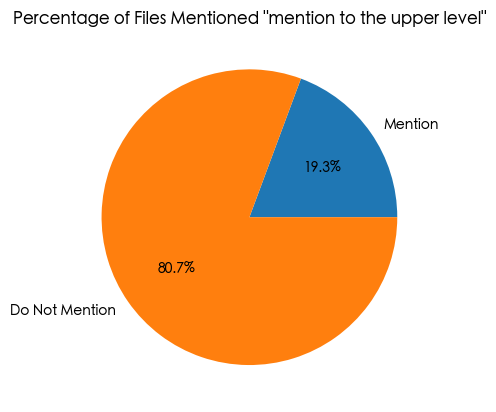

In [9]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "mention to the upper level"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

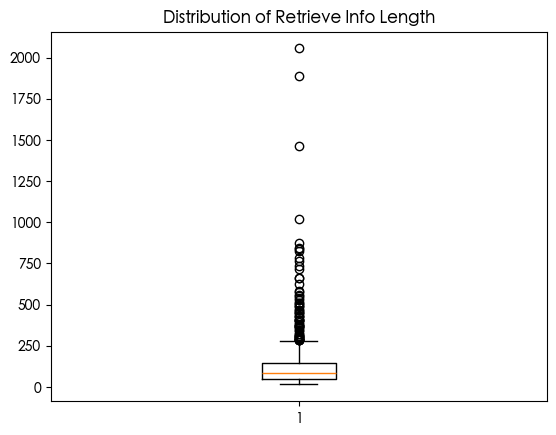

In [10]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

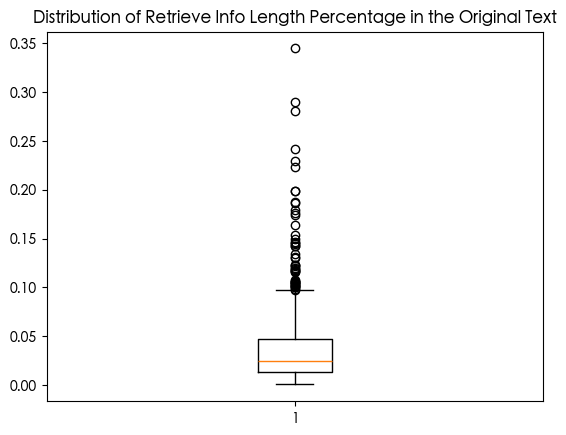

In [11]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [12]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
866,贵州省卫生健康委关于印发《贵州省传染病疫情...(FBM-CLI.12.1581244).txt,各级卫生健康行政部门在政府的统一领导下，负责对传染病疫情信息报告、预警响应和调查处置工作实施监督和管理；组织医疗卫生机构开展传染病疫情的监测、报告、分析、预警响应及现场调查处置工作，并定期组织对上述工作开展情况进行督导评估通报；核实确认发生突发传染病事件时，应在2小时内向同级人民政府和上级卫生健康行政部门报告；并同时组织协调有关部门开展突发传染病事件处置\n负责对本级行政区域内的传染病疫情开展监测、报告、分析和预警响应处置工作，并根据疫情性质、危害程度、波及范围等情况向同级卫生健康行政部门和上级疾病预防控制机构报告；对未达到县级处置标准的聚集性疫情开展监测工作，密切关注疫情发展态势，一旦达到县级处置标准立即开展处置工作；对超出县级处置标准的疫情，应在上级疾病预防控制机构的指导下共同开展流行病学调查、标本采集和实验室检测工作，落实具体防控措施\n负责对本级行政区域内的传染病疫情开展监测、报告、分析和预警响应处置工作，根据疫情性质、危害程度、波及范围等情况向同级卫生健康行政部门和上级疾病预防控制机构报告；按照分级处置原则，负责对达到市（州）级处置标准的传染病疫情进行调查处置，并指导县级疾病预防控制机构开展现场调查、实验室检测，督促落实各项防控措施；对达到县级处置标准的传染病疫情进行技术指导，并定期对县级疾病预防控制机构的预警响应、疫情报告和调查处置等工作情况开展督导评估，并将评估结果上报同级卫生健康行政部门和上级疾病预防控制机构；对超出市（州）级处置标准的疫情，应在上级疾病预防控制机构的指导下共同开展流行病学调查、标本采集和实验室检测工作，落实具体防控措施\n负责全省传染病疫情的监测分析和预警发布，并根据疫情性质、危害程度、波及范围等情况向同级卫生健康行政部门和上级疾病预防控制机构报告；按照分级处置原则，负责对达到省级处置标准的传染病疫情进行调查处置，并指导下级疾病预防控制机构开展现场调查、实验室检测和实施控制措施；对未达到省级处置标准的疫情可根据下级疾病预防控制机构的请求进行技术指导，督促落实各项防控措施；负责对全省各级疾病预防控制机构的预警响应、疫情报告和调查处置等工作情况开展督导评估，并将评估结果上报省级卫生健康行政部门\n对监测发现在同一自然村寨、街道、集体单位（学校、幼儿园、建筑工地等）一日内出现3例及以上，或一周内出现5例及以上的同一种急性传染病或类似症状的病例，立即向属地疾病预防控制机构进行报告，并协助开展传染病疫情调查\n如遇网络、系统故障或疫情发生单位放假无法开展现场调查等特殊情况造成未及时响应和处置的，应立即向市（州）级疾病预防控制机构电话报告并于24小时内提交书面情况说明，各市（州）级疾病预防控制机构汇总后1周内上报省级疾病预防控制机构\n各级疾病预防控制机构接到各种来源的传染病疫情信息均应立即向上级疾病预防控制机构报告\n各级卫生健康行政部门接到疾病预防控制机构突发传染病事件相关信息的报告后，应尽快组织有关专家对事件级别进行认定，如确认为一般及以上级别的事件应立即向同级人民政府及上级卫生健康行政部门书面报告\n各级疾病预防控制机构接到疫情信息后，经调查核实未达到突发公共卫生事件相关信息报告标准的聚集性疫情应在24小时内上报上级疾病预防控制机构；经核实确认达到突发公共卫生事件相关信息报告标准的暴发疫情应在2小时内上报国家突发公共卫生事件信息报告管理系统，并同时向同级卫生健康行政部门和上级疾病预防控制机构报告，其中达到定级标准的突发传染病事件还应在2小时内向同级卫生健康行政部门提交书面定级建议，各级卫生健康行政部门须在收到书面定级建议后及时组织有关专家对事件级别进行认定，并在2小时内向同级人民政府及上级卫生健康行政部门进行书面报告\n责任报告人发现传染病疫情，必须在规定时限内向疫情发生地的县级疾病预防控制机构报告\n各级疾病预防控制机构疫情管理人员在接到报告后，在规定时限内向中心分管领导报告并通知相关业务科室，对核实为突发传染病事件的应向同级卫生健康行政部门和上级疾病预防控制机构报告，并做好疫情信息接报记录\n各级卫生健康行政部门接到疾病预防控制机构突发传染病事件相关信息报告后，立即组织有关专家对事件级别进行认定，对确认为一般及以上级别事件的立即向同级人民政府及上级卫生健康行政部门报告\n各级疾病预防控制机构接到传染病疫情信息报告后，应安排人员立即调查核实，对达到突发公共卫生事件及相关信息报告标准的疫情应在1小时内派出人员进行现场调查，并在到达现场后24小时内向同级卫生健康行政部门和上级疾病预防控制机构提交初步调查报告\n在突发事件调查处置过程中，各级疾病预防控制机构应按照突发事件分级响应原则和应急响应程序，开通应急检测通道，优先检测事件样本，如遇本级实验室条件限制无法开展检测工作的情况，应立即逐级向上级疾病预防控制机构提出委托检测申请，上级疾病预防控制机构接到应急检测委托书及应急样品送检单后，应立即开展样品检测工作，检测结果尽快反馈至委托单位,向同级人民政府和上级卫生健康行政部门报告\n向同级卫生健康行政部门和上级疾病预防控制机构报告\n向同级卫生健康行政部门和上级疾病预防控制机构报告\n向同级卫生健康行政部门和上级疾病预防控制机构报告\n向属地疾病预防控制机构进行报告\n向市（州）级疾病预防控制机构电话报告\n向上级疾病预防控制机构报告\n向同级人民政府及上级卫生健康行政部门书面报告\n向同级卫生健康行政部门和上级疾病预防控制机构报告\n向疫情发生地的县级疾病预防控制机构报告\n向中心分管领导报告\n向同级人民政府及上级卫生健康行政部门报告\n向同级卫生健康行政部门和上级疾病预防控制机构提交初步调查报告\n向上级疾病预防控制机构提出委托检测申请，上级疾病预防控制机构接到应急检测委托书及应急样品送检单后，应立即开展样品检测工作，检测结果尽快反馈,12533,2055,0.163967
2473,湖南省食品药品监督管理局关于发布本局行政执...(FBM-CLI.12.554361).txt,34、销售者未建立并执行进货检查验收制度，审验供货商的经营资格，验明产品合格证明和产品标识，并建立产品进货台账，如实记录产品名称、规格、数量、供货商及其联系方式、进货时间等内容；从事产品批发业务的销售企业未建立产品销售台账，如实记录批发的产品品种、规格、数量、流向等内容，进货台账和销售台账保存期限少于2年；销售者未向供货商按照产品生产批次索要符合法定条件的检验机构出具的检验报告或者由供货商签字或者盖章的检验报告复印件\n36、生产企业和销售者发现其生产的产品存在安全隐患，可能对人体健康和生命安全造成损害，不向社会公布有关信息、通知停止销售使用、告知消费者停止使用、主动召回产品、向有关监督管理部门报告\n60、麻醉药品和精神药品定点生产企业未按照麻醉药品和精神药品年度生产计划安排生产；未依照规定向药品监督管理部门报告生产情况；未依照规定储存麻醉药品和精神药品，或者未依照规定建立、保存专用账册；未依照规定销售麻醉药品和精神药品；未依照规定销毁麻醉药品和精神药品\n75、易制毒化学品生产、经营、购买、运输或者进口、出口单位未按规定建立安全管理制度；将许可证或者备案证明转借他人使用；超出许可的品种、数量生产、经营、购买易制毒化学品；生产、经营、购买单位不记录或者不如实记录交易情况、不按规定保存交易记录或者不如实、不及时向公安机关和有关行政主管部门备案销售情况；易制毒化学品丢失、被盗、被抢后未及时报告，造成严重后果；除个人合法购买第一类中的药品类易制毒化学品药品制剂以及第三类易制毒化学品外，使用现金或者实物进行易制毒化学品交易；易制毒化学品的产品包装和使用说明书不符合本条例规定要求；生产、经营易制毒化学品的单位不如实或者不按时向有关行政主管部门和公安机关报告年度生产、经销和库存等情况\n132、医疗器械生产企业向负责监督检查的（食品）药品监督管理部门隐瞒有关情况、提供虚假材料或者拒绝提供反映其活动情况的真实材料\n161、餐饮服务提供者发生食品安全事故后未立即封存导致或者可能导致食品安全事故的食品及其原料、工具及用具、设备设施和现场，未在2小时之内向所在地县级人民政府卫生部门和食品药品监督管理部门报告并按照相关监管部门的要求采取控制措施\n170、医疗器械生产企业未在规定时间内将召回医疗器械的决定通知到医疗器械经营企业、使用单位或者告知使用者；未按照药品监督管理部门要求采取改正措施或者重新召回医疗器械；未对召回医疗器械的处理做详细记录或者未向药品监督管理部门报告\n172、医疗器械经营企业、使用单位发现其经营、使用的医疗器械存在缺陷，未立即暂停销售或者使用该医疗器械，未及时通知医疗器械生产企业或者供货商、并向所在地省、自治区、直辖市药品监督管理部门报告；使用单位为医疗机构的，未同时向所在地省、自治区、直辖市卫生行政部门报告\n7、销售者未建立并执行进货检查验收制度，审验供货商的经营资格，验明产品合格证明和产品标识，并建立产品进货台账，如实记录产品名称、规格、数量、供货商及其联系方式、进货时间等内容；从事产品批发业务的销售企业未建立产品销售台账，如实记录批发的产品品种、规格、数量、流向等内容，进货台账和销售台账保存期限少于2年；销售者未向供货商按照

In [13]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
2459,上海市科学技术委员会(上海市外国专家局)关于...(FBM-CLI.12.1567399).txt,各用人单位要强化主体责任，严格落实各项防控措施，确保外国专家群体防控疫情工作不留死角，做好本单位外国专家的健康监测，督促从疫情重点地区返沪的外国专家居家或集中隔离医学观察，发现异常情况要按照本市关于疫情属地防控的统一要求，配合相关部门采取相应防控措施，有关情况请及时向市外国专家局报告\n对已经在沪工作的外国专家，应要求其按照有关防疫要求做好自我防护，尽量避免前往人流密集的公共场所，如确需前往，应采取佩戴口罩等防控措施，并避免近距离接触咳嗽、发热人群；对于近期按照工作安排须离境或本人要求离境的外国专家，应向其提供必要协助并明确相关禁忌，做好备案，及时向卫生健康等部门报告；对于按照原工作计划须于近期来沪工作的外国专家，应由各聘用单位向其说明目前情况，严格做好防护工作，必要时应调整工作计划，推迟来华工作安排\n各用人单位要通过多种形式，及时向外国专家发布新型冠状病毒感染的肺炎疫情官方通报和防治指引措施等官方权威信息，提供本市接收疑似新冠病毒肺炎患者发热门诊等医疗服务信息\n认真落实全市联防联控机制，全力配合打好外专系统防控疫情阻击战，采取务实、贴心、到位的举措，帮助外国专家解决实际困难，及时收集相关专业领域外国专家关于疫情防控的意见和建议，并向市外国专家局反馈，凝聚起众志成城、全力以赴、共克时艰的强大正能量，完成好疫情防控特殊时期本市外专工作的重要任务,向市外国专家局报告\n向其提供必要协助并明确相关禁忌，做好备案，及时向卫生健康等部门报告\n向外国专家发布新型冠状病毒感染的肺炎疫情官方通报\n向市外国专家局反馈,1680,579,0.344643
3637,山西省人力资源和社会保障厅转发人力资源和社...(FBM-CLI.12.413714).txt,各级人力资源和社会保障部门、教育部门、卫生部门要将禁止就业歧视的内容纳入日常管理和监督检查中，并在今年7月底前由各市组织一次联合大检查，在8月底前将检查的情况向省人力资源和社会保障厅、教育厅、卫生厅报告\n各级、各部门在执行落实本通知中发生的重大问题，须及时向同级人民政府报告，同时逐级向省人力资源和社会保障厅、省教育厅、省卫生厅报告,向省人力资源和社会保障厅、教育厅、卫生厅报告\n向同级人民政府报告,572,166,0.290210
3998,浙江省审计厅疫情防控工作专班关于调整防控相...(FBM-CLI.12.1620431).txt,一、公职人员直系亲属从国境外返回浙江的，至少提前一天作为重大事项按程序报告，同时要向疫情防控专班通报\n四、厅机关干部职工（含为我厅服务人员）或家属等密切接触者有来自或到访过湖北情况的除按规定向社区报告、做好隔离措施外，要继续落实第一时间报告的要求\n七、厅机关干部职工（含为我厅服务人员）进出办公大楼，取消“测温＋亮码”等管控措施，如绿码发生变化的，要及时向厅人事处报告\n进我厅机关大楼的外来人员要亮码，厅安保服务人员要严格检查督促，如出现不配合的情况要第一时间向厅办公室报告,向疫情防控专班通报\n向社区报告\n向厅人事处报告\n向厅办公室报告,844,237,0.280806


## We can also comparing the statistics results between different labels in our sample by aggrigate the labels from task B ##

In [14]:
df_label = pd.read_csv('policies_label.csv')
df_all = df.join(on='filename', how = 'inner', other = df_label.set_index('filename'))

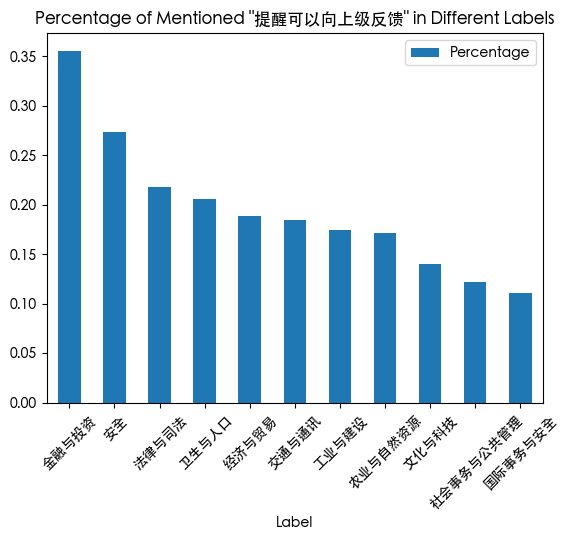

In [15]:
# we use l1 to aggregate the result
agg_result = etrieve_info_length = df_all.groupby('label_L1')

data = []
for name, group in agg_result:
    total = group['Retrieve Info Length'].count()
    mention = group[group['Retrieve Info Length'] != 0]['Retrieve Info Length'].count()
    data.append((name, mention, total, mention/total))

data.sort(key=lambda x: x[3], reverse=True)

# plot the result so we can see the percentage of the mention in different labels
df_plot = pd.DataFrame(data, columns=['Label', 'Mention', 'Total', 'Percentage'])
df_plot.plot(x='Label', y='Percentage', kind='bar')
plt.title('Percentage of Mentioned "提醒可以向上级反馈" in Different Labels')
plt.xticks(rotation=45)
plt.show()

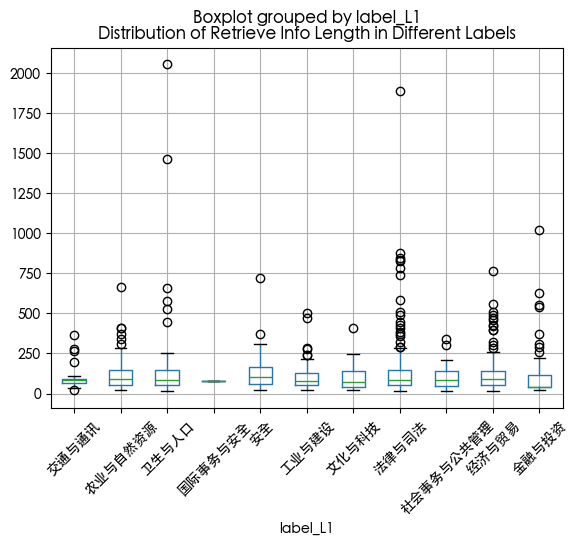

In [16]:
# we can also plot box plot to show the distribution of retrieve info length in different labels
df_temp = df_all.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
df_temp.boxplot(column='Retrieve Info Length', by='label_L1')
plt.title('Distribution of Retrieve Info Length in Different Labels')
plt.xticks(rotation=45)
plt.show()

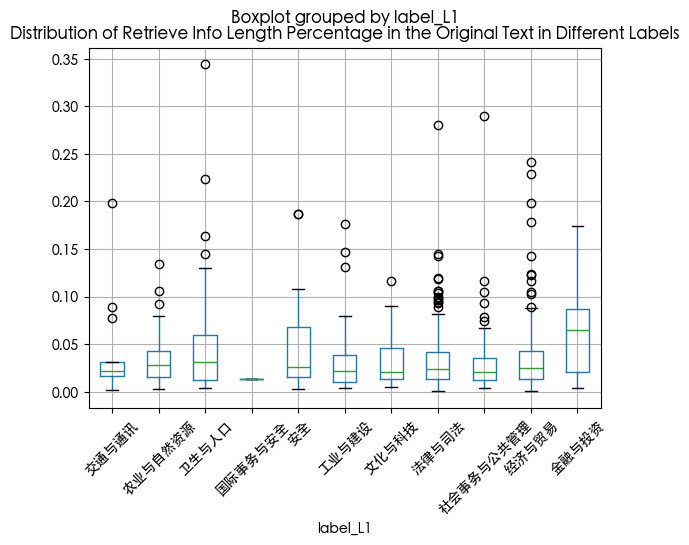

In [17]:
# we can also show the distribution that to what percentage of the document is the retrieve info in different labels
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
df_temp.boxplot(column='Retrieve Info Length Percentage', by='label_L1')
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text in Different Labels')
plt.xticks(rotation=45)
plt.show()